In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.utils.data
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [36]:
# this is a transform to normalize these images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1307,], std=[0.3081,])
])

# Download and load the train and test data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
print(f"MNIST training data loaded: {len(train_dataset)} samples")
print(f"MNIST test data loaded: {len(test_dataset)} samples")

MNIST training data loaded: 60000 samples
MNIST test data loaded: 10000 samples


In [37]:
# Subset the filtered training data to 25% of its size
total_size = len(train_dataset)
# subset_size = total_size // 10
subset_size = 2560

# Generate random indices for the subset
all_indices = list(range(total_size))
random.shuffle(all_indices) # this is in place (who knew?!)
subset_indices = all_indices[:subset_size]

# Create the subset
train_dataset_subset = torch.utils.data.Subset(train_dataset, subset_indices)

print(f"Original training size: {total_size}")
print(f"New 25% subset training size: {len(train_dataset_subset)}")

# Re-assign to train_dataset to use in the existing training loop
train_dataset = train_dataset_subset

Original training size: 60000
New 25% subset training size: 2560


Index: 1955


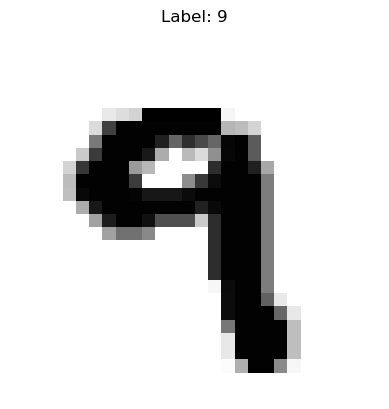

In [38]:
# visualize our input data
def plot_random_train_image(dataset=train_dataset):

    # get random index
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]
    print(f"Index: {idx}")

    # Unnormalize for visualization
    # The original transform was Normalize(mean=[0.1307], std=[0.3081])
    # Formula: unnormalized = (normalized * std) + mean
    mean = 0.1307
    std = 0.3081
    unnormalized_image = image * std + mean

    plt.imshow(unnormalized_image.squeeze(), cmap='gray_r')
    plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

# Plot a random sample from the filtered training data
plot_random_train_image()

In [39]:
# create a CNN class
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Layer 1: 1 input channel (grayscale), 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        # Layer 2: 32 input channels, 64 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout to prevent overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # Fully connected layers
        # After two 2x2 poolings, a 28x28 image becomes 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # First Conv block: Conv -> ReLU -> Pool
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        # Second Conv block: Conv -> ReLU -> Pool
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten the 3D tensor into a 1D vector for the FC layers
        x = torch.flatten(x, 1)

        # Fully connected layers with Dropout
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)

        # We return raw logits (CrossEntropyLoss in PyTorch applies Softmax internally)
        return x

In [40]:
seed = 499
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [41]:
# Create data loaders for CNN using the binary filtered datasets
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# Initialize the model
model = SimpleCNN()

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Lists for tracking metrics
train_losses_batch, val_losses = [], []
train_accuracies_batch, val_accuracies = [], []

# Training loop
epochs = 3

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    batch_no = 0
    model.train()

    for data, target in train_loader:
        batch_no += 1
        train_loss_batch = 0
        train_correct_batch = 0

        optimizer.zero_grad()
        output = model(data)

        # calculate loss and backprop
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss_batch += loss.item()

        # calculate accuracy
        probs = torch.softmax(output, dim=1) # convert logits to probs using softmax
        preds = torch.argmax(probs, dim=1) # find the index that corresponds to the maximum probability
        train_correct_batch += (preds == target).sum().item()
        train_losses_batch.append(train_loss_batch / batch_size)
        train_accuracies_batch.append(train_correct_batch / batch_size)

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0
        val_correct_batch = 0
        with torch.no_grad():

            for data, target in test_loader:

                output = model(data)

                # calculate validation loss
                loss = criterion(output, target)
                val_loss += loss.item()

                # calculate validation accuracy
                probs = torch.softmax(output, dim=1)
                preds = torch.argmax(probs, dim=1)
                val_correct_batch += (preds == target).sum().item()

        val_losses.append(val_loss / len(test_dataset))
        val_accuracies.append(val_correct_batch / len(test_dataset))

        # print the loss and accuracy on the first batch and every tenth thereafter
        if (batch_no == 1) or (batch_no % 10 == 0):
            print('--------------------')
            print(f'Epoch {epoch+1}/{epochs} | Batch {batch_no}')
            print(f'Train Loss: {train_losses_batch[-1]:.4f} | Train Accuracy: {train_accuracies_batch[-1]:.4f}')
            print(f'Val Loss: {val_losses[-1]:.4f} | Val Accuracy: {val_accuracies[-1]:.4f}')
            print()


--------------------
Epoch 1/3 | Batch 1
Train Loss: 0.0360 | Train Accuracy: 0.0781
Val Loss: 0.0002 | Val Accuracy: 0.1234

--------------------
Epoch 1/3 | Batch 10
Train Loss: 0.0347 | Train Accuracy: 0.3594
Val Loss: 0.0002 | Val Accuracy: 0.3521

--------------------
Epoch 1/3 | Batch 20
Train Loss: 0.0335 | Train Accuracy: 0.3750
Val Loss: 0.0002 | Val Accuracy: 0.5033

--------------------
Epoch 1/3 | Batch 30
Train Loss: 0.0307 | Train Accuracy: 0.7188
Val Loss: 0.0002 | Val Accuracy: 0.7637

--------------------
Epoch 1/3 | Batch 40
Train Loss: 0.0273 | Train Accuracy: 0.7500
Val Loss: 0.0002 | Val Accuracy: 0.7201

--------------------
Epoch 2/3 | Batch 1
Train Loss: 0.0283 | Train Accuracy: 0.5000
Val Loss: 0.0002 | Val Accuracy: 0.7060

--------------------
Epoch 2/3 | Batch 10
Train Loss: 0.0237 | Train Accuracy: 0.8281
Val Loss: 0.0002 | Val Accuracy: 0.7708

--------------------
Epoch 2/3 | Batch 20
Train Loss: 0.0196 | Train Accuracy: 0.7656
Val Loss: 0.0001 | Val Accu

In [ ]:
def predict_and_plot(dataset=test_dataset, model=model):
    # Choose a random row from test data
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]

    # Use the model to predict the label
    model.eval()
    with torch.no_grad():
        # Add batch dimension [1, 1, 28, 28]
        input_tensor = image.unsqueeze(0)
        output = model(input_tensor)
        prediction = torch.argmax(torch.softmax(output, dim=1), dim=1).item()

    # Plot the input and display prediction
    # Unnormalize for visualization
    mean, std = 0.1307, 0.3081
    unnormalized_image = image * std + mean

    plt.imshow(unnormalized_image.squeeze(), cmap='gray_r')
    plt.title(f"Test Index: {idx} | Predicted: {prediction} | Actual: {label}")
    plt.axis('off')
    plt.show()


# Run the function
predict_and_plot()

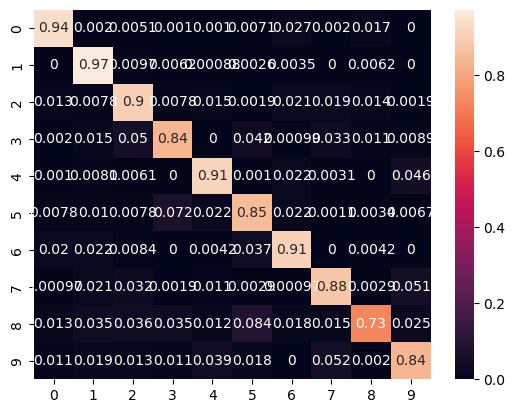

In [43]:
# use the final trained output to predict the test set and create a confusion matrix to display the results
import torch
from torchmetrics.classification import MulticlassConfusionMatrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize with num_classes and normalization option
confmat = MulticlassConfusionMatrix(num_classes=10, normalize='true')
confmat.update(preds, target) # Update with batches
cm = confmat.compute() # Calculate final matrix

# Plot results
sns.heatmap(cm.cpu().numpy(), annot=True)
plt.show()

In [ ]:
# calculate the per-class accuracy for each class